**Prophet**:
- Prophet is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects. It works best with time series that have strong seasonal effects and several seasons of historical data. Prophet is robust to missing data and shifts in the trend, and typically handles outliers well.
- Maybe don't need one that handles missing data if we don't have any

# Inputs

In [ ]:
# Minimum viable dataframe -> two mandatory columns minimum

#Our data should already contain the datetime as index and all features as columns
# Data should be scaled.. Prophet handels target scaling and missings

#Target as extra input also with datetime index

import pandas as pd

df = pd.DataFrame({
    'ds': pd.date_range('2019-01-01', periods=8760, freq='h'),
    'y':  wholesale_price_array   # your target, numeric
})

# ds must be a proper datetime, not a string
df['ds'] = pd.to_datetime(df['ds'])

df.head()

NameError: name 'wholesale_price_array' is not defined

# Dummy inputs

In [22]:
import pandas as pd
import numpy as np

periods = 24 * 365 * 5
ds = pd.date_range('2019-01-01', periods=periods, freq='h')
np.random.seed(42)

hour_effect = 20 * np.sin(2 * np.pi * ds.hour / 24)
day_effect  = 10 * np.sin(2 * np.pi * ds.dayofweek / 7)
trend       = np.linspace(50, 80, periods)
noise       = np.random.normal(0, 5, periods)

df = pd.DataFrame({
    'ds':                    ds,
    'y':                     trend + hour_effect + day_effect + noise,
    'demand_north':          1000 + 200 * np.sin(2 * np.pi * ds.hour / 24) + np.random.normal(0, 20, periods),
    'wind_generation':       300 + 150 * np.random.rand(periods),
    'hydro_storage':         4000 + 500 * np.sin(2 * np.pi * ds.dayofyear / 365) + np.random.normal(0, 50, periods),
    'temperature_auckland':  15 + 8 * np.sin(2 * np.pi * (ds.dayofyear - 15) / 365) + np.random.normal(0, 2, periods),
})
df.head()

,ds,y,demand_north,wind_generation,hydro_storage,temperature_auckland
0,2019-01-01 00:00:00,60.301886,1022.721324,319.974065,3871.757935,11.111119
1,2019-01-01 01:00:00,62.304059,1064.791922,351.705925,3989.218049,10.748063
2,2019-01-01 02:00:00,71.058127,1091.585196,393.946170,3981.493013,12.952032
3,2019-01-01 03:00:00,79.577655,1157.477934,300.700810,4025.567874,14.605369
4,2019-01-01 04:00:00,73.970796,1214.843242,429.794213,4060.059202,13.619390


# Setup

In [23]:
# Install if needed: pip install prophet
from prophet import Prophet

m = Prophet(
    seasonality_mode='multiplicative',   # or 'additive', but for volatile peaks multiplicative should work best
    daily_seasonality=True,         # we'll add custom below
    weekly_seasonality=True,
    yearly_seasonality=True,
)


# Hourly and Seasonality

In [ ]:


# Add hourly cycle (24h period)
m.add_seasonality(
    name='hourly',
    period=1,           # 1 day = 24 periods for hourly data
    fourier_order=8,    # start at 8, tune later. Fourier order = how many sine/cosine waves to use.
)

# Also consider a weekly-hour interaction
m.add_seasonality(
    name='weekly_hourly',
    period=7,
    fourier_order=5,
)

#regressors tell Prophet which columns are used as feature. this loop adds all columns as feature
exclude = ['ds', 'y']  # CHANGE TO ACTUAL NAMES OF DATETIME AND WHOLESALEPIRCE-TARGET COLUMN
regressors = [col for col in df.columns if col not in exclude]

for col in regressors:
    m.add_regressor(col)


# Fit

In [26]:
m.fit(df)

16:29:20 - cmdstanpy - INFO - Chain [1] start processing
16:29:42 - cmdstanpy - INFO - Chain [1] done processing


# Corss validate

In [27]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    m,
    initial='1800 days',   # train on first 2 years
    period='90 days',     # retrain every 30 days
    horizon='1 days',     # evaluate up to 24h ahead
    parallel='processes'  # speeds it up significantly
)

#get and print performance matrix
metrics = performance_metrics(df_cv)
print(metrics[['horizon', 'mae', 'rmse', 'mape']])

Importing plotly failed. Interactive plots will not work.
16:32:57 - cmdstanpy - INFO - Chain [1] start processing
16:33:14 - cmdstanpy - INFO - Chain [1] done processing


           horizon        mae       rmse      mape
0  0 days 02:00:00   5.932995   5.950176  0.080250
1  0 days 03:00:00  10.479316  11.250814  0.152982
2  0 days 04:00:00  10.065341  11.028927  0.142509
3  0 days 05:00:00   6.585190   6.664993  0.081240
4  0 days 06:00:00   5.495113   5.889295  0.064587
5  0 days 07:00:00   2.720012   2.798169  0.029431
6  0 days 08:00:00   2.659927   2.726021  0.028923
7  0 days 09:00:00   1.979715   2.355762  0.021385
8  0 days 10:00:00   0.623367   0.628416  0.007227
9  0 days 11:00:00   0.411263   0.432113  0.004940
10 0 days 12:00:00   3.484508   4.734900  0.042110
11 0 days 13:00:00   3.505871   4.736253  0.042649
12 0 days 14:00:00   2.697761   3.595147  0.038187
13 0 days 15:00:00   5.010983   5.011381  0.073716
14 0 days 16:00:00   3.061519   3.595978  0.048415
15 0 days 17:00:00   0.940912   0.969644  0.017351
16 0 days 18:00:00   1.433891   1.607785  0.028758
17 0 days 19:00:00   4.202868   4.672541  0.077138
18 0 days 20:00:00   5.666622  

/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


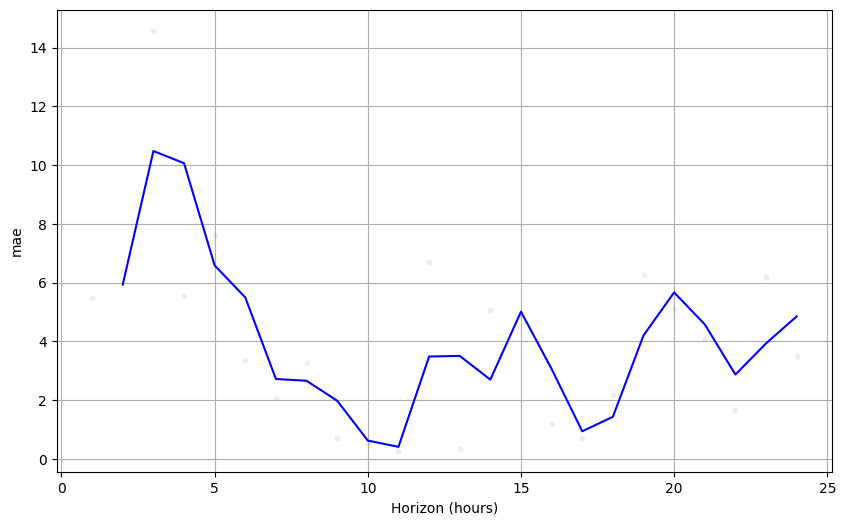

/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


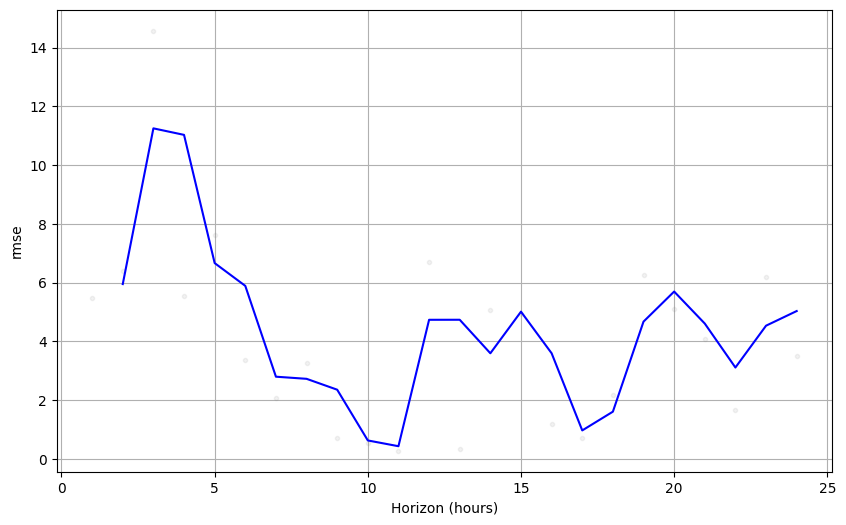

In [28]:
#plot error

from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt

fig1 = plot_cross_validation_metric(df_cv, metric='mae')
plt.show()
plt.close(fig1)

fig2 = plot_cross_validation_metric(df_cv, metric='rmse')
plt.show()
plt.close(fig2)


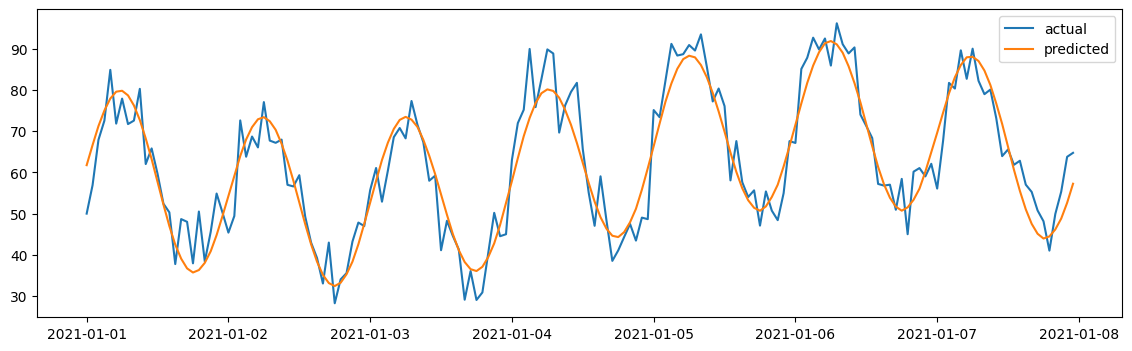

In [29]:
future = df[['ds', 'demand_north', 'wind_generation', 'hydro_storage', 'temperature_auckland']]
forecast = m.predict(future)
mask = (forecast['ds'] >= '2021-01-01') & (forecast['ds'] < '2021-01-08')
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.loc[mask.values, 'ds'], df.loc[mask.values, 'y'], label='actual')
ax.plot(forecast.loc[mask, 'ds'], forecast.loc[mask, 'yhat'], label='predicted')
ax.legend()
plt.show()

# Predict

In [21]:
# We might split it beforehand so we have 24 hours of feature to use to predict the price

# Build a future dataframe for next 24 hours
future = m.make_future_dataframe(
    periods=24,
    freq='h',
    include_history=False   # just the forecast window
)

# Attach regressor forecasts for those 24 hours
future['demand_north']      = demand_forecast_24h
future['wind_generation']    = wind_forecast_24h
future['hydro_storage']     = hydro_now   # relatively static
future['temperature_auckland'] = temp_forecast_24h

forecast = m.predict(future)

# Key output columns:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

NameError: name 'demand_forecast_24h' is not defined